# Lecture 06

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from IPython import display

For this in-class we will experiment with optimizers that are commonly used in deep learning systems. We will use a toy 1D function (one parameter), for simplicity and visualiztion purposes. However, note that in practice the functions being optimized have millions of parameters, are very noisy, and can change each iteration. Therefore, use this assignment to gain some intuition on the optimizers and their parameters, however, take any conclusions with a grain of salt. 

We will perform numerical optimization on the following 1D function:

$$f(w) = w^4 - 21w^3 + 151w^2 - 435w + 550$$

In [2]:
def f(w):
    return 1*w**4 - 21*w**3 + 151*w**2 - 435*w + 550

In the `utils.py` file, a function called `optimize` is provided to run an optimization loop for a given function and optimizer. Additionally, a function called `save_fig` is provied for saving a GIF of the optimization trajectory.

In [3]:
from utils import optimize, save_gif
help(optimize)
help(save_gif)

Help on function optimize in module utils:

optimize(func, optimizer)
    Peforms optimization of the func function using the provided Pytorch optimizer
    
    Inputs:
    - func (function): function to be optimized
    - optimzier (torch.optim.Optimizer): Pytorch optimizer instance
    
    Returns:
    - xsnp (1D NumPy array): history of weight values
    - ysnp (1D NumPy array): history of function values

Help on function save_gif in module utils:

save_gif(func, x, y, fn)
    Creats GIF of optimization trajectory
    
    Inputs:
    - func (function): function to be optimized
    - x (1D NumPy array): values of weight during training
    - y (1D NumPy array): corresponding function value y = func(x)
    - fn (string): filename to save GIF
    
    Returns:
    - anim (annimation.FuncAnimation): annimation.FuncAnimation object



First, perform optimization using the stochastic gradient descent (SGD) optimizer. For SGD the only parameter to tune is the learning rate (`lr`). Experiment with different learning rate values below. 

MovieWriter ffmpeg unavailable; using Pillow instead.


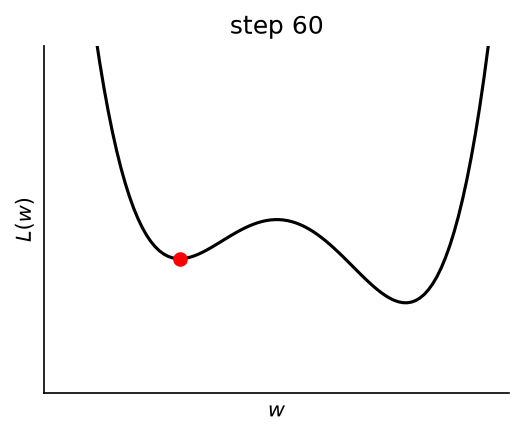

In [19]:
w = torch.nn.Parameter(torch.ones(1))
w.requires_grad = True

######################################
#######         TODO           #######
######################################
optimizer = torch.optim.SGD([w], lr = .01)

ws,fs = optimize(f, optimizer)
anim = save_gif(f, ws, fs, "sgd.gif")

The above plot only shows the final state of the optimization. The previous cell saved a GIF of the full trajectory to the current working directory, which you can open using the file browser. Alternatively, for convenience, you can use the code below to display an inline gif. **NOTE** if the gif is running when you try to save the notebook as a PDF, you will get an error. After you are done expiermenting and ready to save, right click on the cell below and select "Clear Cell Output"

In [ ]:
# inline gif display
gifPath = "sgd.gif" 
with open(gifPath,'rb') as myfile:
    display.Image(data=myfile.read(), format='png')

Which values of `lr` work the best? What happens if `lr` is too small? Too large? Does SGD find the global minimum?

## Answer: I found a learning rate between .05 to .1 was most ideal. If the LR is too small, say .0001, the model updates very slowly and training in this manner can take days or several hours. Also the model can get stuck in local minima. Conversely, if the lr is too large the model takes steps so massive that it overshoots the valley of low loss. Additionally, the model might oscillate back and forth across the optimal valley. Lastly, No, Stochastic Gradient Descent (SGD) does not guarantee finding the global minimum, as in practive ANN have millions of parameters with several hills, and saddle points. Also, there is a risk of overfitting the training data

Next try the SGD + momentum optimizer. SGD + momentum is implemented in the `torch.optim.SGD` class by setting the `momentum` parameter to a value greater than 0 (default is 0, corresponding to vanilla SGD which was used in the previous optimization). Experiment with different combinations of learning rate (lr) and momentum.

MovieWriter ffmpeg unavailable; using Pillow instead.


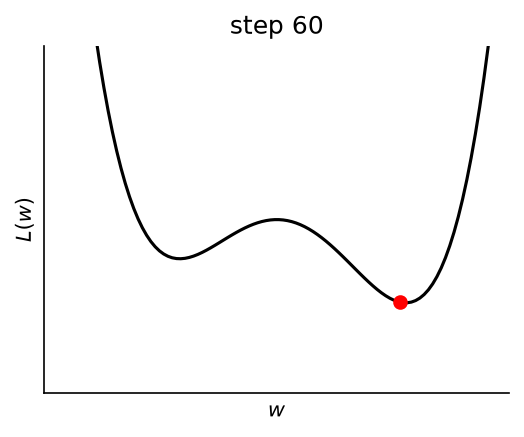

In [18]:
w = torch.nn.Parameter(torch.ones(1))
w.requires_grad = True

######################################
#######         TODO           #######
######################################
optimizer = torch.optim.SGD([w], lr = .01, momentum = .9)  #Lr = XXX and Mom = XXX

ws,fs = optimize(f, optimizer)
anim = save_gif(f, ws, fs, "momentum.gif")

Display inline GIF of SGD + momentum optimization trajectory

In [ ]:
# inline gif display
gifPath = "momentum.gif" 
with open(gifPath,'rb') as myfile:
    display.Image(data=myfile.read(), format='png')

Which values of `lr` work the best? What happens if `lr` is too small or too large?
Which values of `momentum` work the best? What happens if `momentum` is too small or too large?
Does the optimization reach a global minimum?

## Answer: a learning rate in the range of 0.01–0.1 is well‑conditioned. If the learning rate is too small, training becomes very slow and may get stuck. if it is too large, the updates overshoot, causing divergence or oscillation. Momentum values around 0.8–0.95 were found to be most ideal because they smooth the progess. Very small momentum behaves almost like plain SGD, while very large momentum can cause unstable updates. Overall, the optimization almost never reaches a true global minimum—instead, it converges to a good local minimum or a flat basin that generalizes well.

Last, perform optimization using the Adam optimizer. Experiment with the learning rate (`lr`) and coefficients used for computing running averages of gradient and its square (`betas`: tuple of 2 elements)

MovieWriter ffmpeg unavailable; using Pillow instead.


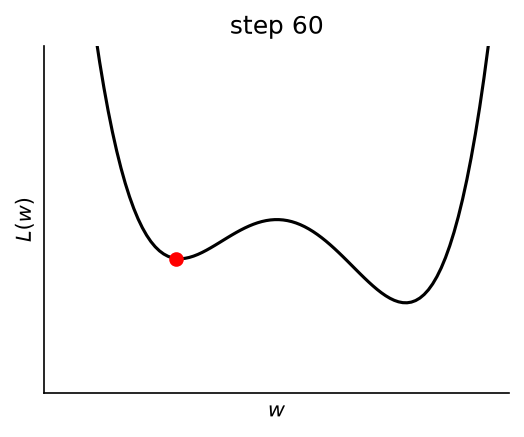

In [15]:
w = torch.nn.Parameter(torch.ones(1))
w.requires_grad = True

######################################
#######         TODO           #######
######################################
optimizer = torch.optim.Adam([w], lr = .1, betas=(.9, .95))

ws,fs = optimize(f, optimizer)
anim = save_gif(f, ws, fs, "adam.gif")

Display inline GIF of Adam optimization trajectory

In [ ]:
# inline gif display
gifPath = "adam.gif" 
with open(gifPath,'rb') as myfile:
    display.Image(data=myfile.read(), format='png')

Which values of lr work the best? Which vaues of betas work the best? Does Adam reach a global minimum?

## Answer: I used a a learning rate of .05 which seem to provide decent movement of the optimizer. For beta values I used a rate of .9 and .95 for B1 and B2 respectively. I found the beta values to provide a strong smoothing of the estimates without making the model too sluggish. Adam does not guarantee reaching a global minimum in deep learning; instead, it converges to a good local minimum or a flat region that generalizes well.

Compare and contrast the 3 optimizers used in this assignment. How are the trajectories the same vs. different? 

## Answer: SGD moves in a straightforward but noisy path, taking small steps directly along the gradient. Adding momentum smooths that path—like giving the optimizer a more stable bcurve toward a minimum. Adam’s trajectory looks very different, it adapts its step sizes per parameter, often taking sharper, more confident turns. All three head toward good minima, but Adam tends to navigate better, while SGD and SGD+momentum follow more uniform paths.

# Submit

Save a PDF and submit to ICON. **NOTE** the notebook cannot be exported as a PDF with the inline GIFs playing. Clear the output of each of the 3 cells that have inline GIFs (cells that start wtih  `# inline gif display`), then proceed with exporting as PDF.

Add, commit, push to your lecture git repo.